In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
!wget https://archive.ics.uci.edu/static/public/240/human+activity+recognition+using+smartphones.zip


--2026-02-10 05:40:39--  https://archive.ics.uci.edu/static/public/240/human+activity+recognition+using+smartphones.zip
Resolving archive.ics.uci.edu (archive.ics.uci.edu)... 128.195.10.252
Connecting to archive.ics.uci.edu (archive.ics.uci.edu)|128.195.10.252|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: unspecified
Saving to: ‘human+activity+recognition+using+smartphones.zip’

human+activity+reco     [         <=>        ]  58.18M  33.8MB/s    in 1.7s    

2026-02-10 05:40:41 (33.8 MB/s) - ‘human+activity+recognition+using+smartphones.zip’ saved [61005872]



In [3]:
!unzip human+activity+recognition+using+smartphones.zip

Archive:  human+activity+recognition+using+smartphones.zip
 extracting: UCI HAR Dataset.names   
 extracting: UCI HAR Dataset.zip     


In [4]:
!unzip "UCI HAR Dataset.zip"

Archive:  UCI HAR Dataset.zip
   creating: UCI HAR Dataset/
  inflating: UCI HAR Dataset/.DS_Store  
   creating: __MACOSX/
   creating: __MACOSX/UCI HAR Dataset/
  inflating: __MACOSX/UCI HAR Dataset/._.DS_Store  
  inflating: UCI HAR Dataset/activity_labels.txt  
  inflating: __MACOSX/UCI HAR Dataset/._activity_labels.txt  
  inflating: UCI HAR Dataset/features.txt  
  inflating: __MACOSX/UCI HAR Dataset/._features.txt  
  inflating: UCI HAR Dataset/features_info.txt  
  inflating: __MACOSX/UCI HAR Dataset/._features_info.txt  
  inflating: UCI HAR Dataset/README.txt  
  inflating: __MACOSX/UCI HAR Dataset/._README.txt  
   creating: UCI HAR Dataset/test/
   creating: UCI HAR Dataset/test/Inertial Signals/
  inflating: UCI HAR Dataset/test/Inertial Signals/body_acc_x_test.txt  
   creating: __MACOSX/UCI HAR Dataset/test/
   creating: __MACOSX/UCI HAR Dataset/test/Inertial Signals/
  inflating: __MACOSX/UCI HAR Dataset/test/Inertial Signals/._body_acc_x_test.txt  
  inflating: UCI HAR

In [5]:
import os

print(os.listdir())
print(os.listdir('UCI HAR Dataset'))
print(os.listdir("UCI HAR Dataset/train"))
print(os.listdir("UCI HAR Dataset/train/Inertial Signals"))

['.config', 'human+activity+recognition+using+smartphones.zip', 'UCI HAR Dataset.names', 'UCI HAR Dataset', '__MACOSX', 'UCI HAR Dataset.zip', 'sample_data']
['features.txt', 'README.txt', 'train', '.DS_Store', 'test', 'features_info.txt', 'activity_labels.txt']
['Inertial Signals', 'X_train.txt', 'subject_train.txt', 'y_train.txt']
['body_gyro_y_train.txt', 'total_acc_x_train.txt', 'body_acc_z_train.txt', 'body_acc_x_train.txt', 'total_acc_y_train.txt', 'body_gyro_x_train.txt', 'body_acc_y_train.txt', 'body_gyro_z_train.txt', 'total_acc_z_train.txt']


In [6]:
from tensorflow.keras.utils import to_categorical

BASE_PATH = 'UCI HAR Dataset'

SIGNALS = [
    "body_acc_x_{}.txt",
    "body_acc_y_{}.txt",
    "body_acc_z_{}.txt",
    "body_gyro_x_{}.txt",
    "body_gyro_y_{}.txt",
    "body_gyro_z_{}.txt"
]

def load_split(split):
  signals = []
  for signal in SIGNALS:
    path = os.path.join(
        BASE_PATH,
        split,
        "Inertial Signals",
        signal.format(split)
    )
    signals.append(np.loadtxt(path))

  X = np.stack(signals, axis = -1)
  y = np.loadtxt(
        os.path.join(BASE_PATH, split, f"y_{split}.txt")
    ) - 1  # shift labels from 1–6 → 0–5

  y = to_categorical(y, num_classes=6)
  return X, y

X_train, y_train = load_split("train")
X_test, y_test = load_split("test")

print("Train:", X_train.shape, y_train.shape)
print("Test:", X_test.shape, y_test.shape)

Train: (7352, 128, 6) (7352, 6)
Test: (2947, 128, 6) (2947, 6)


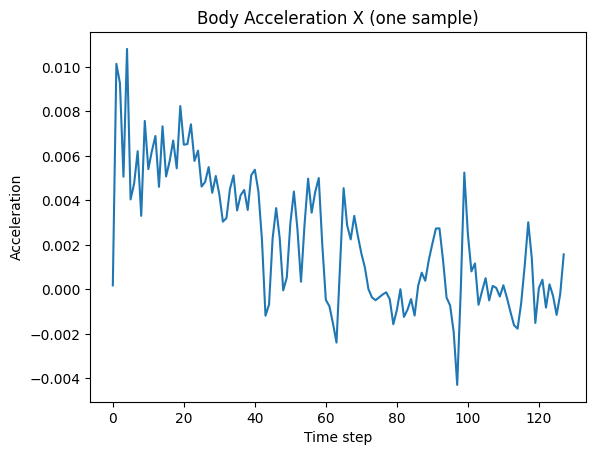

In [7]:
import matplotlib.pyplot as plt

plt.plot(X_train[0, :, 0])  # body_acc_x
plt.title("Body Acceleration X (one sample)")
plt.xlabel("Time step")
plt.ylabel("Acceleration")
plt.show()


In [12]:
from sklearn.preprocessing import StandardScaler
import numpy as np

def scale_data(X_train, X_test):
    n_train, t, f = X_train.shape
    n_test = X_test.shape[0]

    scaler = StandardScaler()

    # reshape to (samples*time, features)
    X_train_2d = X_train.reshape(-1, f)
    X_test_2d = X_test.reshape(-1, f)

    # fit ONLY on training data
    scaler.fit(X_train_2d)

    # transform
    X_train_scaled = scaler.transform(X_train_2d)
    X_test_scaled = scaler.transform(X_test_2d)

    # reshape back
    X_train_scaled = X_train_scaled.reshape(n_train, t, f)
    X_test_scaled = X_test_scaled.reshape(n_test, t, f)

    return X_train_scaled, X_test_scaled

In [13]:
X_train_scaled, X_test_scaled = scale_data(X_train, X_test)

print(X_train_scaled.mean(axis=(0,1)))
print(X_train_scaled.std(axis=(0,1)))

[ 3.44693707e-17  2.92595375e-17  5.41681091e-17  1.45763019e-16
  5.82972795e-17 -5.83237062e-17]
[1. 1. 1. 1. 1. 1.]


In [11]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D, MaxPooling1D
from tensorflow.keras.layers import LSTM, Dense, Dropout, Bidirectional

model = Sequential([
    Conv1D(64, 3, activation='relu', input_shape=(128, 6)),
    MaxPooling1D(2),

    Conv1D(128, 3, activation='relu'),

    Bidirectional(LSTM(64)),
    Dropout(0.3),

    Dense(64, activation='relu'),
    Dense(6, activation='softmax')
])

model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)


model.summary()



Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d_2 (Conv1D)               │ (None, 126, 64)        │         1,216 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_1 (MaxPooling1D)  │ (None, 63, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_3 (Conv1D)               │ (None, 61, 128)        │        24,704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_1 (Bidirectional) │ (None, 128)            │        98,816 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 6)              │           390 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 133,382 (521.02 KB)

 Trainable params: 133,382 (521.02 KB)

 Non-trainable params: 0 (0.00 B)

In [14]:
from tensorflow.keras.callbacks import EarlyStopping
early = EarlyStopping(
    monitor = 'val_loss',
    patience = 5,
    restore_best_weights=True
)

history = model.fit(
    X_train_scaled,
    y_train,
    epochs=50,
    batch_size=64,
    validation_split=0.2,
    callbacks=[early],
    verbose=1
)

test_loss, test_acc = model.evaluate(
    X_test_scaled,
    y_test,
    verbose=0
)

print(f"Test accuracy: {test_acc:.4f}")

Epoch 1/50
92/92 ━━━━━━━━━━━━━━━━━━━━ 30s 278ms/step - accuracy: 0.3576 - loss: 1.3794 - val_accuracy: 0.6377 - val_loss: 0.6980
Epoch 2/50
92/92 ━━━━━━━━━━━━━━━━━━━━ 32s 184ms/step - accuracy: 0.6236 - loss: 0.6931 - val_accuracy: 0.6438 - val_loss: 0.6144
Epoch 3/50
92/92 ━━━━━━━━━━━━━━━━━━━━ 16s 169ms/step - accuracy: 0.6672 - loss: 0.6025 - val_accuracy: 0.7260 - val_loss: 0.5954
Epoch 4/50
92/92 ━━━━━━━━━━━━━━━━━━━━ 15s 167ms/step - accuracy: 0.6852 - loss: 0.5859 - val_accuracy: 0.6560 - val_loss: 0.5843
Epoch 5/50
92/92 ━━━━━━━━━━━━━━━━━━━━ 15s 164ms/step - accuracy: 0.7488 - loss: 0.5021 - val_accuracy: 0.7865 - val_loss: 0.4469
Epoch 6/50
92/92 ━━━━━━━━━━━━━━━━━━━━ 18s 193ms/step - accuracy: 0.8145 - loss: 0.3981 - val_accuracy: 0.8504 - val_loss: 0.3529
Epoch 7/50
92/92 ━━━━━━━━━━━━━━━━━━━━ 18s 169ms/step - accuracy: 0.8385 - loss: 0.3494 - val_accuracy: 0.8640 - val_loss: 0.3445
Epoch 8/50
92/92 ━━━━━━━━━━━━━━━━━━━━ 26s 225ms/step - accuracy: 0.8435 - loss: 0.3403 - val_accu

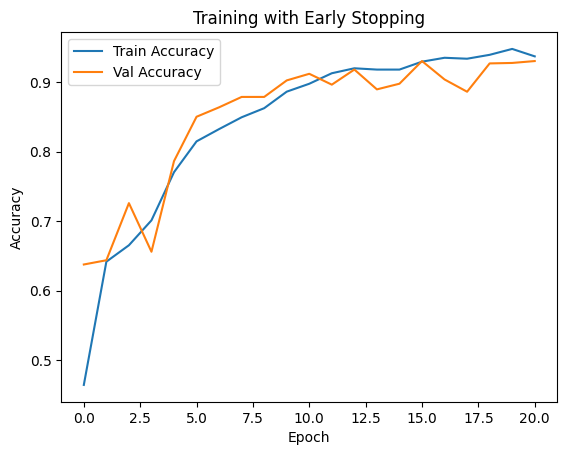

In [15]:
import matplotlib.pyplot as plt

plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Val Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.title('Training with Early Stopping')
plt.show()


93/93 ━━━━━━━━━━━━━━━━━━━━ 3s 25ms/step


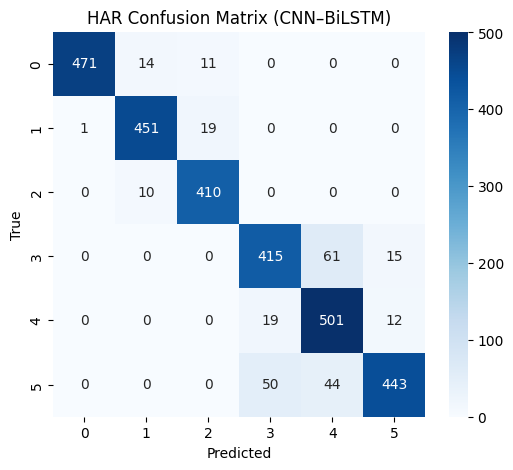

In [17]:
import numpy as np
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

y_pred = model.predict(X_test_scaled)
y_true = np.argmax(y_test, axis=1)
y_pred_labels = np.argmax(y_pred, axis=1)

cm = confusion_matrix(y_true, y_pred_labels)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("HAR Confusion Matrix (CNN–BiLSTM)")
plt.show()


In [19]:
model.save("har_cnn_bilstm_model.keras")

In [20]:
from google.colab import files

files.download("har_cnn_bilstm_model.keras")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>